## imports

In [2]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist, pdist
from scipy.signal import resample
from scipy.stats import zscore, pearsonr, circmean
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
from pycircstat.tests import rayleigh
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns

%matplotlib inline

## set paths

In [3]:
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [4]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## shorten some frequent variables

In [5]:
pred_trajs = participant_trajectories['prediction']
avg_pred_traj = avg_participant_trajectories['prediction']
pred_events = participant_events['prediction']
avg_pred_events = avg_participant_events['prediction']
atlep2_traj = episode_trajectories['atlep2']
atlep2_events = episode_events['atlep2']
atlep2_rec_trajs = participant_trajectories['atlep2']
avg_atlep2_rec_traj = avg_participant_trajectories['atlep2']
atlep2_rec_events = participant_events['atlep2']
avg_atlep2_rec_events = avg_participant_events['atlep2']
arrdev_events = episode_events['arrdev']
arrdev_rec_events = participant_events['arrdev']

## define some functions

In [6]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [7]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [8]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

In [9]:
def corr_pearsonr(rs1, rs2):
    return _z2r(np.array(pearsonr(_r2z(np.array(rs1)), _r2z(np.array(rs2)))))

In [10]:
# ## for plotting error bars
# def ribbon(M, color='k', alpha=0.5):    
#     x = np.arange(M.shape[0])
#     y = np.mean(M, axis=1)
#     ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
#     h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
#     h2 = plt.plot(x, y, color=color)
#     return h1, h2

In [11]:
# stashing correlation CI calcualtion for now -- wrong use case?
def ribbon(M, color='k', alpha=0.5, label=None, corrs=False):    
    x = np.arange(M.shape[0])
    
    if corrs:
        y = corr_mean(M, axis=1)
    else:
        y = np.mean(M, axis=1)
        
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
        
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color, label=label)
    return h1, h2

## filter events with no predictions from average prediction events

In [210]:
# no_rec_mask = np.all(np.equal(avg_pred_events, 0), axis=1)
# avg_pred_events = avg_pred_events[~no_rec_mask]

## filter atlep2 recall events with no recalls from average

In [211]:
# no_rec_mask = np.all(np.equal(avg_atlep2_rec_events, 0), axis=1)
# avg_atlep2_rec_events = avg_atlep2_rec_events[~no_rec_mask]

# does an event's "predictability" relate to its "memorability?"

In [192]:
pred_props = np.empty((len(pred_events), atlep2_events.shape[0]))
for ix, (turkid1, p_ev) in enumerate(pred_events):
    
    # get prediction event mappings
    prediction_mappings = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
    
    # what proportion of predicted events were about each atlep2 event?
    sub_pred_prop = np.zeros((atlep2_events.shape[0]))
    uniques, counts = np.unique(prediction_mappings, return_counts=True)
    for ev, n in dict(zip(uniques, counts)).items():
        sub_pred_prop[ev] = n/prediction_mappings.shape[0]
    
    pred_props[ix] = sub_pred_prop
    
predictability = pred_props.mean(axis=0)
memorability = np.diag(1-cdist(atlep2_events, avg_atlep2_rec_events, 'correlation'))

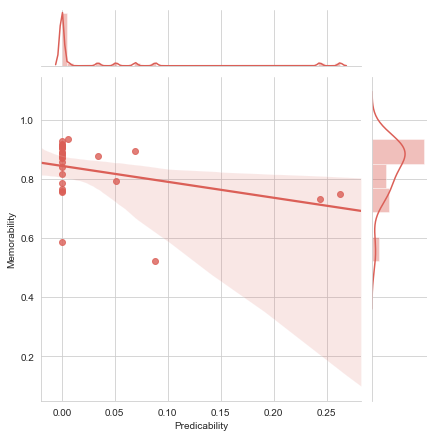

In [193]:
ax = sns.jointplot(predictability, memorability, kind='reg')
ax.set_axis_labels('Predicability','Memorability')

In [194]:
predictability = np.zeros((atlep2_events.shape[0]))
for ix, (turkid1, p_ev) in enumerate(pred_events):
    
    # get prediction event mappings
    prediction_mappings = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
    
    for pred_ev in prediction_mappings:
        predictability[pred_ev] += 1
    
#     # what proportion of predicted events were about each atlep2 event?
#     sub_pred_prop = np.zeros((atlep2_events.shape[0]))
#     uniques, counts = np.unique(prediction_mappings, return_counts=True)
#     for ev, n in dict(zip(uniques, counts)).items():
#         sub_pred_prop[ev] = n/prediction_mappings.shape[0]
    
#     pred_props[ix] = sub_pred_prop
    
#predicability = pred_props.mean(axis=0)
memorability = np.diag(1-cdist(atlep2_events, avg_atlep2_rec_events, 'correlation'))

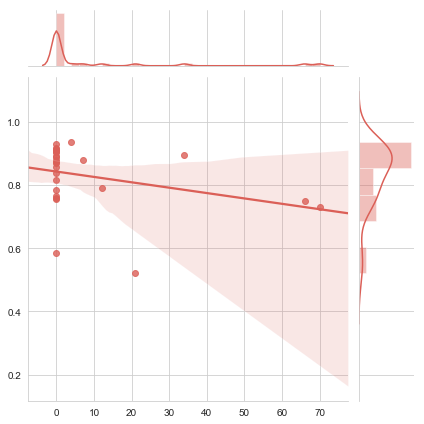

In [195]:
sns.jointplot(predictability, memorability, kind='reg')

In [196]:
predictability = np.zeros((atlep2_events.shape[0]))
memorability = np.zeros((atlep2_events.shape[0]))

for ix, (turkid1, p_ev) in enumerate(pred_events):
    
    # get prediction event mappings
    prediction_mappings = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
    
    for pred_ev in prediction_mappings:
        predictability[pred_ev] += 1
        
for ix, (turkid2, r_ev) in enumerate(atlep2_rec_events):
    
    # get atlep2 recall mappings
    a2rec_mappings = next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2)
    
    for r_ev in a2rec_mappings:
        memorability[r_ev] += 1

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/seaborn/axisgrid.py:1847: UserWarning: JointGrid annotation is deprecated and will be removed in a future release.
  warnings.warn(UserWarning(msg))


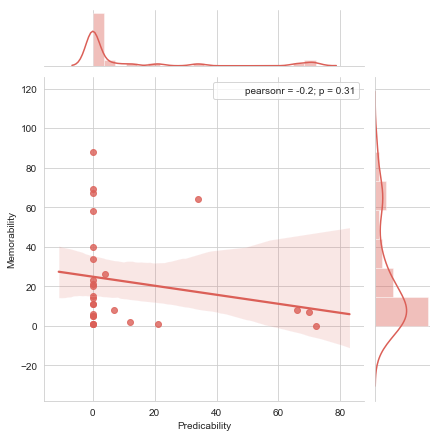

In [197]:
ax = sns.jointplot(predictability, memorability, kind='reg', stat_func=pearsonr)
ax.set_axis_labels('Predicability','Memorability')

## does content of prediction relate to content of eventually remembered moments?

In [ ]:
# list of correlation coefficients per subject
pred_corrs = []
rec_corrs = []
# for each participant who viewed atlep2
for turkid2, events in participant_events['atlep2']:
    # get their across-session study ID and session 1 psiturk ID
    sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 2'] == turkid2)
    
    # get their prediction and atlep2 recall trajectories
    sub_pred_traj = next(p_traj for tid, p_traj in pred_trajs if tid == turkid1)
    sub_atlep2_rec_traj = next(r_traj for tid, r_traj in atlep2_rec_trajs if tid == turkid2)
    
    tpt_pred_corr = []
    tpt_rec_corr = []
    # for each prediction timepoint
    for tpt in sub_pred_traj:
        # find the most similar atlep2 TIMEPOINT and its index
        maxcorr_p = np.max(1-cdist(np.atleast_2d(tpt),atlep2_traj, 'correlation'))
        maxcorr_ix = np.argmax(1-cdist(np.atleast_2d(tpt), atlep2_traj, 'correlation'))
        
        # find distance from that atlep2 timepoint to nearest recall timepoint
        maxcorr_r = np.max(1-cdist([atlep2_traj[maxcorr_ix]], sub_atlep2_rec_traj, 'correlation'))
        
        tpt_pred_corr.append(maxcorr_p)
        tpt_rec_corr.append(maxcorr_r)
        
    pred_corrs.append(corr_mean(tpt_pred_corr))
    rec_corrs.append(corr_mean(tpt_rec_corr))

    #corrs.append(list(pearsonr(tpt_pred_dist, tpt_rec_dist)))

#print(np.mean(corrs, axis=0))

In [ ]:
sns.jointplot(pred_corrs, rec_corrs, kind='reg', stat_func=corr_pearsonr)

## are atlep2 recalls "pulled toward" predictions?

In [15]:
# # for each participant who viewed atlep2
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session study ID and session 1 psiturk ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)
#     # get their atlep2 episode-recall event mappings
#     recall_mappings = next(maps for tid, maps in event_mappings['atlep2'] if tid==turkid2)
#     # and get their atlep2 episode-prediction event mappings
#     pred_mappings = next(maps for tid, maps in event_mappings['prediction'] if tid==turkid1)
    
#     # for each prediction event
#     for recall_event in events:
#         # get the vector from the corresponding episode event to that prediction event
        

In [57]:
# # for each subject and their atlep2 recall events
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session ID and session 1 ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)

#     # get the atlep2 events they predicted
#     prediction_events = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
    
#     # get their prediction/atlep2 and atlep2/recall event mappings
#     prediction_mappings = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
#     atlep2_mappings = next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2)
    
#     # for each predicted event
#     for i in prediction_mappings:
#         get the 
#         meanpred = prediction_events[np.where(prediction_mappings==i)].mean(axis=0)
        

# #     # index mask for predicted events later recalled
# #     inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
# #     # if any events were both predicted and recalled
# #     if any(inboth_ix):
        
# #         # displacement vector and between each predicted atlep2 event and its prediction, and unit vector
# #         pred_ep_disp = sub_pred_evs[np.where(np.isin(sub_pred_mappings, inboth_ix))] - atlep2_events[inboth_ix]
# #         pred_ep_direc = pred_ep_disp / np.absolute(pred_ep_disp)

# #         # find the displacement vector between the episode event and their later recall of it, and unit vector
# #         ep_rec_disp = atlep2_events[inboth_ix] - sub_atlep2_rec_evs[np.where(np.isin(sub_atlep2_rec_mappings, inboth_ix))]
# #         ep_rec_direc = ep_rec_disp / np.absolute(ep_rec_disp)


# #         prediction_event_effects.loc[sid] = [pred_ep_disp, pred_ep_direc, ep_rec_disp, ep_rec_direc]
        
# # prediction_event_effects.dropna(inplace=True)



## compare prediction content to episode 2 content (WIP)

In [172]:
[i[1] for i in pred_events]

[array([[2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 1.14030876e-02, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.80071115e-01, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.35391971e-01, 2.94719488e-04,
         2.94719488e-04, 6.71808381e-02, 2.94719488e-04, 2.94719488e-04,
         2.94719488e-04, 2.94719488e-04, 2.94719488e-04, 2.94719488e-04,
         8.48946799e-02, 2.94719488e-04, 2.94719488

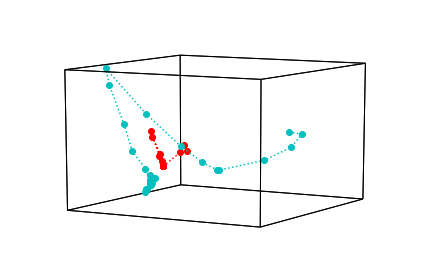

In [180]:
hyp.plot([avg_participant_events['prediction']]+[episode_events['atlep2']], fmt=
         ['ro:','co:','go:'])

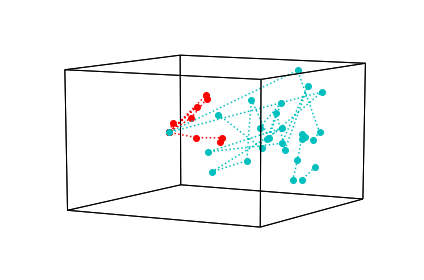

In [168]:
hyp.plot([avg_participant_events['prediction']]+[avg_participant_events['atlep2']], fmt=
         ['ro:','co:'])

# angles

## does prediction content influence event memory?

In [155]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

[10  0 11]
[23 23 23]
[23 10 11 11 11 11]
[ 9  9  1 10  9  9  9  9  9  0  0]
[23 23 10 10 10  9 25]


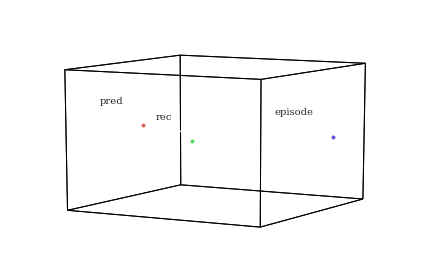

[23  9  9]


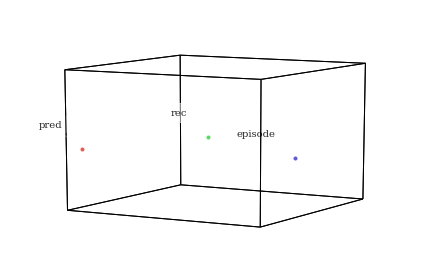

[23  9 23  9]
[23 23  2 10 10 10 23 23 23  9 10  9]


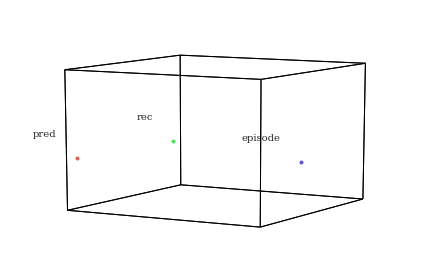

[23 23]
[2 2]


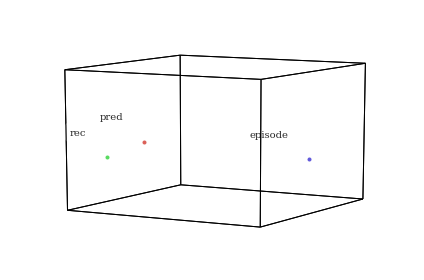

[1 9 9]
[10 10  0 23]
[10 10  9 23 23]
[ 2  2 23  9  9 10 23 23 23 23 23 23 23  0]


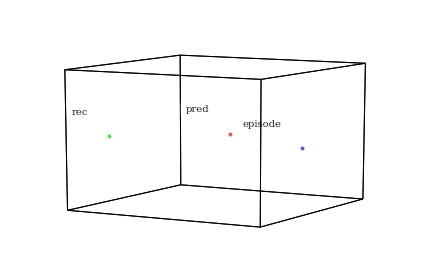

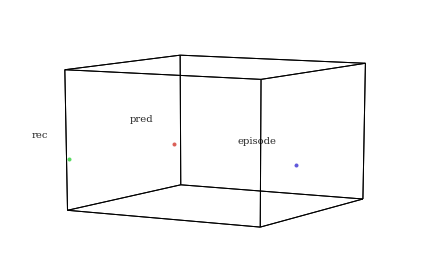

[23  0  0 10 10  9  9]
[23  2  2]
[10 10 10  9  9 25  9]


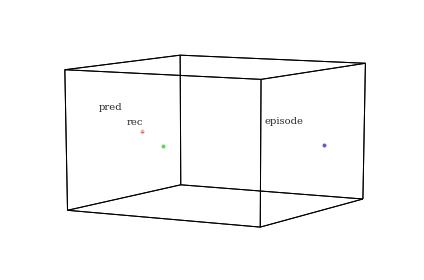

[23 23  0]
[23  9]
[11 11]
[0 9]
[ 0  0  0  0  0  0  0 10 10 10 10 10 10 10 10  0  0  0  0  0  0  0  0 25
  0  0]


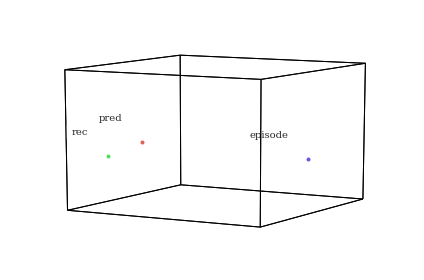

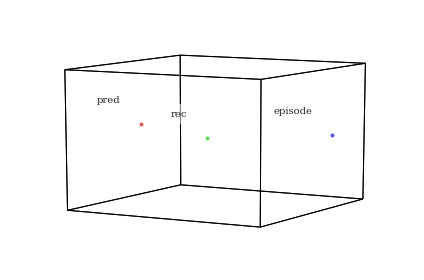

[10  9 10]
[10  9]
[10  2  9]
[ 9 10  2  2]


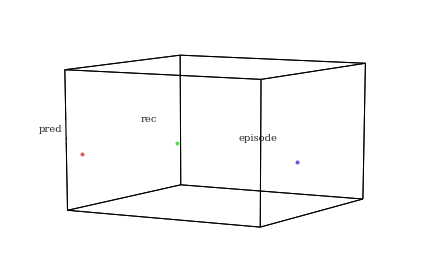

[1 9]
[23 23]
[9 9 9 9]
[23  9]
(1.4317084798057558e-05, 7.963279698610178)


In [163]:
sub_cmeans = []
# for each subject and their atlep2 recall events
for turkid2, events in participant_events['atlep2']:
    # get their across-session ID and session 1 ID
    sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 2'] == turkid2)

    # get the atlep2 events they predicted and those they remembered later
    sub_pred_evs = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
    sub_atlep2_rec_evs = next(r_evs for tid, r_evs in atlep2_rec_events if tid == turkid2)
    
    # get their prediction/atlep2 and atlep2/recall event mappings
    sub_pred_mappings = next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1)
    sub_atlep2_rec_mappings = next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2)
    
    
    # index mask for predicted events later recalled
    inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
    # if any events were both predicted and recalled
    if any(inboth_ix):
        sub_angles = np.empty(np.unique(inboth_ix).shape[0])
        for ix, i in enumerate(np.unique(inboth_ix)):
            
            # get best prediction and recall event for each pairing
            pred_options = sub_pred_evs[np.where(sub_pred_mappings == i)]
            best_pred = pred_options[np.argmax(1-cdist(np.atleast_2d(pred_options), np.atleast_2d(atlep2_events[i]), 
                         'correlation'))]
            rec_options = sub_atlep2_rec_evs[np.where(sub_atlep2_rec_mappings == i)]
            best_rec = rec_options[np.argmax(1-cdist(np.atleast_2d(rec_options), np.atleast_2d(atlep2_events[i]), 
                         'correlation'))]
            
            # get angle between displacement vectors
            sub_angles[ix] = np.arccos((np.dot(best_rec - atlep2_events[i], best_pred - atlep2_events[i])) /
                                       (np.linalg.norm(best_pred - atlep2_events[i]) * 
                                        np.linalg.norm(best_rec - atlep2_events[i])))
            
#             hyp.plot([np.atleast_2d(best_pred), np.atleast_2d(best_rec), np.atleast_2d(atlep2_events[i])],
#                     labels=['pred','rec','episode'], size=[])
        # find circular mean
        sub_cmeans.append(circmean(sub_angles))
        
print(rayleigh(np.array(sub_cmeans)))

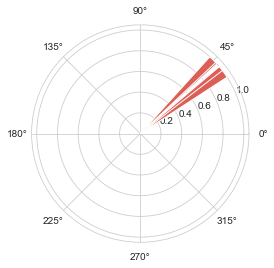

In [164]:
N = 80
max_height = 4

width = (2*np.pi) / N

ax = plt.subplot(111, polar=True)
bars = ax.bar(sub_cmeans, 1, width=width)

plt.show()

In [158]:
sub_cmeans

[0.7792941516491255,
 0.7783082956417511,
 0.795640460197067,
 0.6355239134078559,
 0.6590533289039717,
 0.6691954193277594,
 0.6633230763398772,
 0.6158022589736215]

## control analysis: repeat with best matching arrdev event

### map prediction events to best matching arrested development events

[2 2 2 0 0]


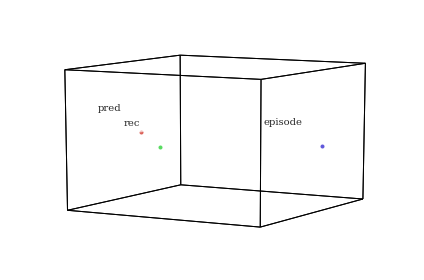

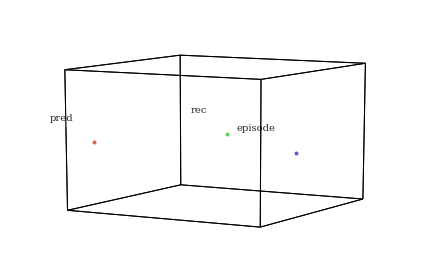

[0 0]
[2 0]
[2 2 2 2]
[ 2  2 27  2]


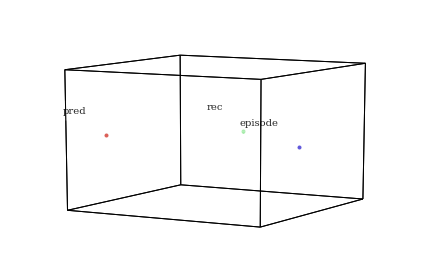

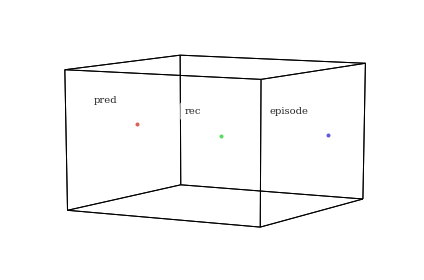

[2 2 0]


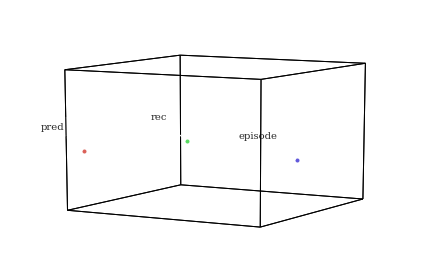

[2 2 0 0]


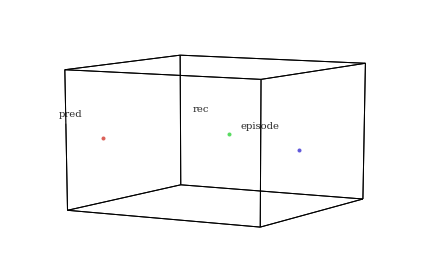

[2 2 2]


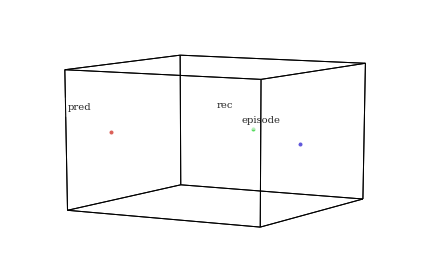

[2 2]


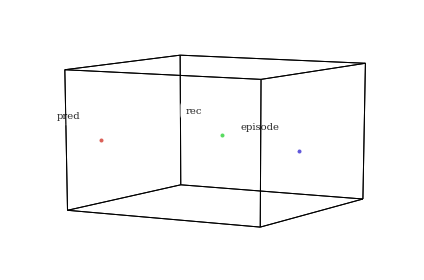

[2 2 2 2 2 2 0 2]
[ 2  2  0  0 27]


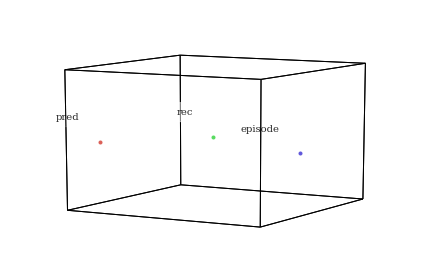

[0 0]
[2 2 2]
[2 2]
[2 2]
[2 0]


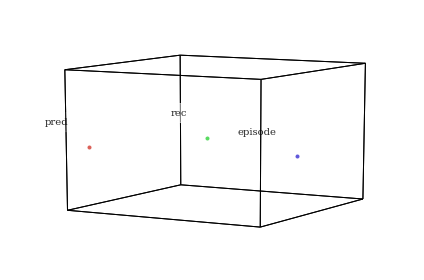

[ 0  0 27  0  0  0 27  0 27 27  2 27 27 27]


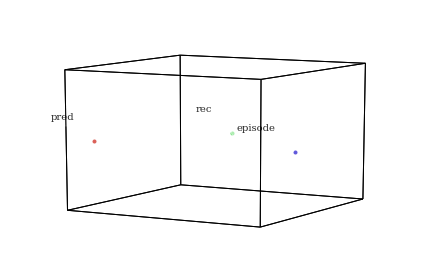

[2 2 0]
[2 2 2 2 2]
[2 2 2 2 2]


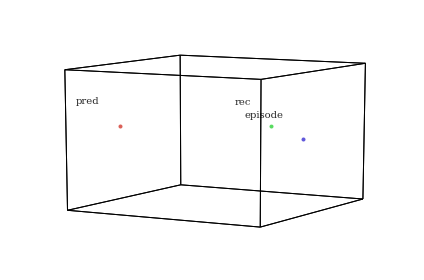

[2 2]


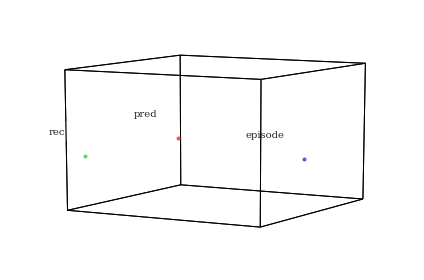

[2 2]


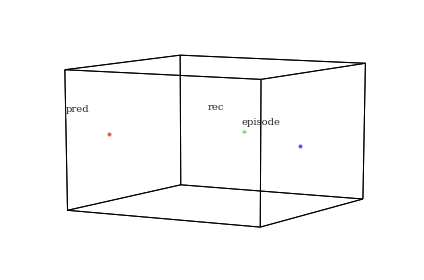

[0 2 2 2 2 2 2 2 0 0 2]


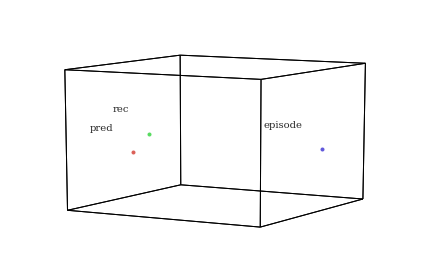

[2 2 2 2]
[ 0  0  0  0  0  0 27]
[2 2]


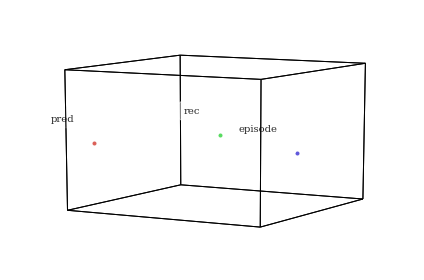

[2 2]


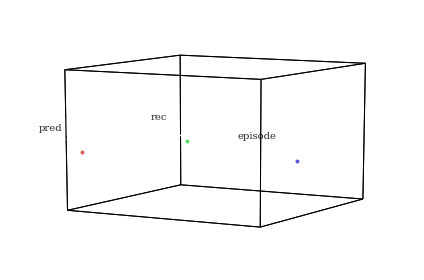

[0 2]
[ 2  0  0  0  2  2  2  2  2  2  2  2  2  2  2  2  2  2  0 27  2]
(1.104918009072639e-10, 14.93019687610355)


In [165]:
sub_cmeans = []
# for each subject and their arrdev recall events
for turkid2, events in participant_events['arrdev']:
    # get their across-session ID and session 1 ID
    sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 2'] == turkid2)

    # get the atlep2 events they predicted and arrdev events they remembered later
    sub_pred_evs = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
    sub_arrdev_rec_evs = next(r_evs for tid, r_evs in arrdev_rec_events if tid == turkid2)
    
    # get their prediction/arrdev and arrdev/recall event mappings
    sub_pred_mappings = np.array([np.argmax(1 - cdist(arrdev_events, sub_pred_evs, 'correlation'), axis=0)])[0]
    sub_arrdev_rec_mappings = next(ms for tid, ms in event_mappings['arrdev'] if tid == turkid2)
    
    # index mask for predicted events later recalled
    inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_arrdev_rec_mappings)]
        
    # if any events were both predicted and recalled
    if any(inboth_ix):
        sub_angles = np.empty(np.unique(inboth_ix).shape[0])
        for ix, i in enumerate(np.unique(inboth_ix)):
            
            # get best prediction and recall event for each pairing
            pred_options = sub_pred_evs[np.where(sub_pred_mappings == i)]
            best_pred = pred_options[np.argmax(1-cdist(np.atleast_2d(pred_options), np.atleast_2d(arrdev_events[i]), 
                         'correlation'))]
            rec_options = sub_arrdev_rec_evs[np.where(sub_arrdev_rec_mappings == i)]
            best_rec = rec_options[np.argmax(1-cdist(np.atleast_2d(rec_options), np.atleast_2d(arrdev_events[i]), 
                         'correlation'))]
            
            # get angle between displacement vectors
            sub_angles[ix] = np.arccos((np.dot(best_rec - arrdev_events[i], best_pred - arrdev_events[i])) /
                                       (np.linalg.norm(best_pred - arrdev_events[i]) * 
                                        np.linalg.norm(best_rec - arrdev_events[i])))
            
            hyp.plot([np.atleast_2d(best_pred), np.atleast_2d(best_rec), np.atleast_2d(arrdev_events[i])],
                    labels=['pred','rec','episode'])
        # find circular mean
        sub_cmeans.append(circmean(sub_angles))
        
print(rayleigh(np.array(sub_cmeans)))

In [166]:
np.radians((np.dot(best_rec - arrdev_events[i], best_pred - arrdev_events[i])) /
                                       (np.linalg.norm(best_pred - arrdev_events[i]) * 
                                        np.linalg.norm(best_rec - arrdev_events[i])))

0.013735145547836357

In [152]:
sub_cmeans

[0.7611886386168258,
 0.8041206915901491,
 0.8023141782208953,
 0.7931339974986517,
 0.7536078490967488,
 0.806138275647234,
 0.8345466182523417,
 0.7632630686716988,
 0.7068895614383637,
 0.7330111085898618,
 0.6681649952615161,
 0.7769033034048702,
 0.6944817821759989,
 0.7594328291820328,
 0.7869658708889262]

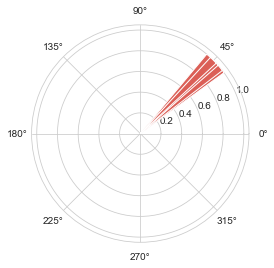

In [149]:
N = 80
max_height = 4

width = (2*np.pi) / N

ax = plt.subplot(111, polar=True)
bars = ax.bar(sub_cmeans, 1, width=width)

plt.show()

In [122]:
sub_pred_mappings.shape

(11,)

ValueError: XA and XB must have the same number of columns (i.e. feature dimension.)

In [90]:
np.atleast_2d(rec_options).shape

(1, 2)

In [89]:
np.atleast_2d(arrdev_events[i]).shape

(1, 100)

In [112]:
# # NOTE: lots of issues with repeat event matches, using first occurence of event mappings

# prediction_event_effects = pd.DataFrame(index=list(id_maps.keys()), 
#                                         columns=['pred_ep_disp','pred_ep_direc','ep_rec_disp','ep_rec_direc'])
# # for each subject and their atlep2 recall events
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session ID and session 1 ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)

#     # get the atlep2 events they predicted and those they remembered later
#     sub_pred_evs = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
#     sub_atlep2_rec_evs = next(r_evs for tid, r_evs in atlep2_rec_events if tid == turkid2)
    
#     # get their prediction/atlep2 and atlep2/recall event mappings
#     sub_pred_mappings = np.unique(next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1))
#     sub_atlep2_rec_mappings = np.unique(next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2))

#     # index mask for predicted events later recalled
#     inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
#     # if any events were both predicted and recalled
#     if any(inboth_ix):
        
#         # displacement vector and between each predicted atlep2 event and its prediction, and unit vector
#         pred_ep_disp = sub_pred_evs[np.where(np.isin(sub_pred_mappings, inboth_ix))] - atlep2_events[inboth_ix]
#         pred_ep_direc = pred_ep_disp / np.absolute(pred_ep_disp)

#         # find the displacement vector between the episode event and their later recall of it, and unit vector
#         ep_rec_disp = atlep2_events[inboth_ix] - sub_atlep2_rec_evs[np.where(np.isin(sub_atlep2_rec_mappings, inboth_ix))]
#         ep_rec_direc = ep_rec_disp / np.absolute(ep_rec_disp)


#         prediction_event_effects.loc[sid] = [pred_ep_disp, pred_ep_direc, ep_rec_disp, ep_rec_direc]
        
# prediction_event_effects.dropna(inplace=True)



In [25]:
# prediction_event_effects

## does how an episode 2 event was predicted affect how it was later remembered?

In [18]:
# # NOTE: lots of issues with repeat event matches, using first occurence of event mappings

# prediction_event_effects = pd.DataFrame(index=list(id_maps.keys()), 
#                                         columns=['pred_ep_disp','pred_ep_direc','ep_rec_disp','ep_rec_direc'])
# # for each subject and their atlep2 recall events
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session ID and session 1 ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)

#     # get the atlep2 events they predicted and those they remembered later
#     sub_pred_evs = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
#     sub_atlep2_rec_evs = next(r_evs for tid, r_evs in atlep2_rec_events if tid == turkid2)
    
#     # get their prediction/atlep2 and atlep2/recall event mappings
#     sub_pred_mappings = np.unique(next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1))
#     sub_atlep2_rec_mappings = np.unique(next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2))

#     # index mask for predicted events later recalled
#     inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
#     # if any events were both predicted and recalled
#     if any(inboth_ix):
        
#         # displacement vector and between each predicted atlep2 event and its prediction, and unit vector
#         pred_ep_disp = sub_pred_evs[np.where(np.isin(sub_pred_mappings, inboth_ix))] - atlep2_events[inboth_ix]
#         pred_ep_direc = pred_ep_disp / np.absolute(pred_ep_disp)

#         # find the displacement vector between the episode event and their later recall of it, and unit vector
#         ep_rec_disp = atlep2_events[inboth_ix] - sub_atlep2_rec_evs[np.where(np.isin(sub_atlep2_rec_mappings, inboth_ix))]
#         ep_rec_direc = ep_rec_disp / np.absolute(ep_rec_disp)


#         prediction_event_effects.loc[sid] = [pred_ep_disp, pred_ep_direc, ep_rec_disp, ep_rec_direc]
        
# prediction_event_effects.dropna(inplace=True)



In [19]:
# for row, data in prediction_event_effects.iterrows():
#     prediction_event_effects.at[row, 'dist_corr'] = np.diag(1-cdist(np.atleast_2d(data['pred_ep_disp']), 
#         np.atleast_2d(data['ep_rec_disp']), 'correlation')).mean()

#     prediction_event_effects.at[row, 'direc_corr'] = np.diag(1-cdist(np.atleast_2d(data['pred_ep_direc']), 
#         np.atleast_2d(data['ep_rec_direc']), 'correlation')).mean()

In [25]:
# prediction_event_effects

# embeddings

### define classes, functions

In [91]:
class Point:
    def __init__(self, coord=None):
        self.coord = np.array(coord)

In [92]:
class LineSegment:  
    def __init__(self, p1=None, p2=None):
        if isinstance(p1, Point):
            self.p1 = p1
        else:
            self.p1 = Point(p1)
            
        if isinstance(p2, Point):
            self.p2 = p2
        else:
            self.p2 = Point(p2)
        
    def intersect(self, z):
        if isinstance(z, Circle):
            return _seg_intersect_circle(self, z)
        elif isinstance(x, Rectangle):
            return _seg_intersect_rect(self, z)
        
    def norm(self):
        diff = self.p2.coord-self.p1.coord
        return diff/np.linalg.norm(diff)
    
    def get_p1(self):
        return self.p1.coord
    
    def get_p2(self):
        return self.p2.coord
    
    def get_vec(self):
        return self.p2.coord-self.p1.coord
        
    def angle(self, ref=None):
        if ref==None:
            p1 = np.zeros_like(self.get_p1())
            p2 = np.zeros_like(self.get_p1())
            p2[0] = 1
            ref = LineSegment(p1, p2)
        v0 = ref.get_vec()
        v1 = self.get_vec()
        return np.arccos(v0.dot(v1)/(np.linalg.norm(v0)*np.linalg.norm(v1)))

In [93]:
class Circle:
    def __init__(self, center=None, r=None):
        self.center = np.array(center)
        self.r = r 
    
    def get_center(self):
        return self.center
    
    def get_radius(self):
        return self.r

In [94]:
class Rectangle:
    def __init__(self, x=None, y=None, w=None):
        self.c0 = x-w
        self.c1 = y-w
        self.c2 = x+w
        self.c3 = y+w

In [95]:
def _seg_intersect_circle(ls, circ):
     
    Q = circ.get_center()
    r = circ.get_radius()
    P1 = ls.get_p1()
    V = ls.get_p2() - P1
    
    a = V.dot(V)
    b = 2 * V.dot(P1 - Q)
    c = P1.dot(P1) + Q.dot(Q) - 2 * P1.dot(Q) - r**2
    
    disc = b**2 - 4 * a * c
    if disc < 0:
        return False
    
    sqrt_disc = math.sqrt(disc)
    t1 = (-b + sqrt_disc) / (2 * a)
    t2 = (-b - sqrt_disc) / (2 * a)
    if not (0 <= t1 <= 1 or 0 <= t2 <= 1):
        return False
    
    return True

In [96]:
def _seg_intersect_rect(ls, r):
    
    # find min/max X for the segment
    minX = min(ls.p1.x, ls.p2.x)
    maxX = max(ls.p1.x, ls.p2.x)
    
    # find the intersection of the segment's and rectangle's x-projections
    if maxX > r.c2:
        maxX = r.c2
    if minX < r.c0:
        minX = r.c0
    
    if minX > maxX:
        return False
    
    minY = ls.p1.y
    maxY = ls.p2.y
    
    dx = ls.p2.x - ls.p1.x
    
    if abs(dx) > .0000001:
        a = (ls.p2.y - ls.p1.y) / dx
        b = ls.p1.y - a * ls.p1.x
        minY = a * minX + b
        maxY = a * maxX + b
        
    if minY > maxY:
        tmp = maxY
        maxY = minY
        minY = tmp
        
    # find the intersection of the segment's and rectangle's y-projections
    if maxY > r.c3:
        maxY = r.c3
    if minY < r.c1:
        minY = r.c1
        
    # if Y-projections do not intersect return false
    if minY > maxY:
        return False
    else:
        return True

In [97]:
def add_arrows(axes, x, y, **kwargs):

    # spacing of arrows
    aspace = .05 # good value for scale of 1
    aspace *= scale

    # r is the distance spanned between pairs of points
    r = [0]
    for i in range(1,len(x)):
        dx = x[i]-x[i-1]
        dy = y[i]-y[i-1]
        r.append(np.sqrt(dx*dx+dy*dy))
    r = np.array(r)

    # rtot is a cumulative sum of r, it's used to save time
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())

    arrowData = [] # will hold tuples of x,y,theta for each arrow
    arrowPos = 0 # current point on walk along data
    rcount = 1 
    while arrowPos < r.sum():
        x1,x2 = x[rcount-1],x[rcount]
        y1,y2 = y[rcount-1],y[rcount]
        da = arrowPos-rtot[rcount] 
        theta = np.arctan2((x2-x1),(y2-y1))
        ax = np.sin(theta)*da+x1
        ay = np.cos(theta)*da+y1
        arrowData.append((ax,ay,theta))
        arrowPos+=aspace
        while arrowPos > rtot[rcount+1]: 
            rcount+=1
            if arrowPos > rtot[-1]:
                break

    # could be done in above block if you want
    for ax,ay,theta in arrowData:
        # use aspace as a guide for size and length of things
        # scaling factors were chosen by experimenting a bit
        axes.arrow(ax,ay,
                   np.sin(theta)*aspace/10,np.cos(theta)*aspace/10, 
                   head_width=aspace/3, **kwargs)

In [98]:
def compute_coord(xi, yi, w, seglist, kind='rectangle'):
    
    if kind=='rectangle':
        z = Rectangle(x=xi, y=yi, w=w)
    elif kind=='circle':
        z = Circle(center=[xi,yi], r=w)
        
    segs = list(filter(lambda s: s.intersect(z), seglist))
    
    if len(segs)>1:
        u, v  = np.array([seg.norm() for seg in segs]).mean(0)
        rads = np.array([seg.angle() for seg in segs])
        p, z = pycircstat.tests.rayleigh(rads)
    else:
        u = 0
        v = 0
        p = 1
    c = len(segs)
    return u, v, p, c

In [21]:
atlep2_event_times[23]

(1082, 1139)

In [17]:
with open(pickle_dir+'eventseg-models/atlep2_event_times.p', 'rb') as f:
    atlep2_event_times = pickle.load(f)

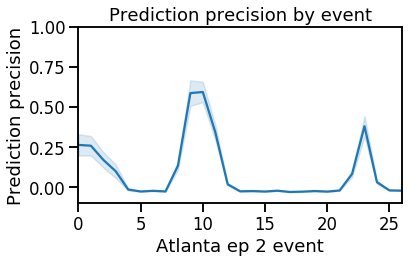

In [15]:
sns.set_context('talk')
dists = []
for ep_event in atlep2_events:
    dist = []
    for turkid, sub in pred_events:
        dist.append(np.max(1-cdist(np.atleast_2d(ep_event), sub, 'correlation')))
    dists.append(dist)
    
dists = np.array(dists)
ribbon(dists, color='#1f77b4', corrs=True, alpha=.15)
plt.ylim(-.1,1)
plt.xlim(0,26)
plt.title('Prediction precision by event')
plt.xlabel('Atlanta ep 2 event')
plt.ylabel('Prediction precision')
plt.tight_layout()
plt.show()

In [ ]:
# z-transforming means with 95% CI ribbon
sns.set_context('talk')

ep_rec_dists = {k : None for k in episode_events.keys()}

for episode, episode_es in episode_events.items():
    if episode == 'atlep1':
        title = 'Atlanta episode 1 (immediate)'
    elif episode == 'atlep2':
        title = 'Atlanta episode 2'
    elif episode == 'arrdev':
        title = 'Arrested Development'
    else:
        title = 'Atlanta episode 1 (delayed)'
        
    dists = []
    for ep_e in episode_es:
        dist = []
        for turkid, sub in participant_events[episode]:
            dist.append(np.max(1-cdist(np.atleast_2d(ep_e), sub, 'correlation')))
        dists.append(dist)
    ep_rec_dists[episode] = np.array(dists)
    
#     df = pd.DataFrame(dists)
#     df['Average correlation'] = _z2r(_r2z(pd.DataFrame(dists)).mean(axis=1))
#     df = df.melt(var_name='subject', value_name='Average correlation')
#     df['Event number'] = list(range(episode_es.shape[0]))*(df.subject.max()+1)
#     df['Event number'] = df.index
#     sns.lineplot(x='Event number', y='Average correlation', data=df)

    # FOR NOW: exclude last event due to edge effect from window calculation
    dists = np.array(dists)[:-1]
#     ep_rec_dists[episode] = dists
    
    ribbon(dists, color='#1f77b4', corrs=True, alpha=.15)
#     meandists = dists.mean(axis=1)
    meandists = corr_mean(dists, axis=1)
    
    if episode == 'atlep1':
        immediate_dists = meandists
    elif episode == 'delayed':
        delayed_dists = meandists
        
    xmax = meandists.argsort()[-3:]
    ymax = meandists[xmax]
    xmin = meandists.argsort()[:3]
    ymin = meandists[xmin]
    
    plt.plot(xmax, ymax+.1, 'gv', markersize=8)
    plt.plot(xmin, ymin-.1, 'r^', markersize=8)
    
    plt.title(title)
    if episode == 'arrdev':
        plt.xlim(0, dists.shape[0]-.5)
    else:
        plt.xlim(0, dists.shape[0]-1)
    plt.ylim(0, 1.05)
    plt.tight_layout()
#     plt.savefig(fig_dir+'{}_event_memorability.pdf'.format(episode))
    plt.show()

In [22]:
with open('../../data/annotations_dfs/atlep1.p', 'rb') as f:
    atlep1 = pickle.load(f)

In [74]:
atlep1.loc[122]

Frame                                                                               9036
Onset time                                                                        361.44
Narrative details (external events)    Swiff asks if Earn wants to come party with hi...
Narrative details (internal state)     Earn feels like he is missing out on having fu...
Characters on screen                                                         Swiff, Earn
Music presence                                                                        no
Speech                                 Hey we gonna hit two dollar Tuesday at the Alt...
Character speaking                                                                 Swiff
Indoor/outdoor                                                                    indoor
Setting                                                                          Airport
Scene name                                                            Earn's Airport Job
Name: 122, dtype: obj

In [75]:
atlep1.loc[122].values

array([9036, 361.44,
       'Swiff asks if Earn wants to come party with him tonight. Earn stares straight ahead.',
       'Earn feels like he is missing out on having fun because he has a daughter and responsibilities.',
       'Swiff, Earn', 'no',
       'Hey we gonna hit two dollar Tuesday at the Alta, you wanna roll?',
       'Swiff', 'indoor', 'Airport', "Earn's Airport Job"], dtype=object)